# Inference and Evaluation of Pretrained E. coli FluxTransformers

Explore and visualize the behavior of a pretrained FluxTransformer model on E. coli metabolism. Includes loss curves, diagnostic plots for chosen fluxes, PCA and t-SNE plots, and flux metrics.

In [1]:
import os
import random
from datetime import date

import torch
from torch import nn
import torch.nn.functional as F
import numpy as np
import pandas as pd
from IPython.display import display, Image

from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
from sklearn.metrics import r2_score, mean_absolute_error

import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import matplotlib.patches as mpatches
import seaborn as sns
from matplotlib.animation import FuncAnimation, PillowWriter
from openTSNE import TSNEEmbedding, affinity, initialization

from ecoli_core_merged_transformer import load_data, prepare_tensors, set_seed

%matplotlib inline
pd.set_option('display.max_rows', None)

In [2]:
class AttentionBlock(nn.Module):
    """Multi-head attention block with per-head diffusion of c."""
    def __init__(self, d_model=128, n_heads=8, dropout=0.05):
        super().__init__()
        assert d_model % n_heads == 0, "d_model must be divisible by n_heads"

        self.d_model = d_model
        self.n_heads = n_heads

        self.layer_norm = nn.LayerNorm(d_model)

        self.mha = nn.MultiheadAttention(
            embed_dim=d_model,
            num_heads=n_heads,
            dropout=dropout,
            batch_first=True,
        )

        # Learnable head aggregation
        self.head_scores = nn.Parameter(torch.zeros(n_heads))

    def forward(self, x, c):
        """
        x: (B, S, d_model)
        c: (B, S, 1)
        returns: x_out (B, S, d_model), c_out (B, S, 1)
        """
        x_norm = self.layer_norm(x)

        # Get per-head attention weights: (B, H, S, S)
        attn_out, attn_weights = self.mha(
            x_norm, x_norm, x_norm,
            need_weights=True,
            average_attn_weights=False
        )
        
        x_out = attn_out + x

        # Per-head diffusion of c:
        # (B, H, S, S) @ (B, 1, S, 1) -> (B, H, S, 1)
        c_heads = torch.matmul(attn_weights, c.unsqueeze(1))
        alpha = F.softmax(self.head_scores, dim=0).view(1, self.n_heads, 1, 1)  # (1,H,1,1)
        c_att = (c_heads * alpha).sum(dim=1)  # (B, S, 1)

        c_out = c_att + c

        return x_out, c_out


In [3]:
class FeedForwardBlock(nn.Module):
    def __init__(self, d_model, d_ff, dropout=0.05):
        super().__init__()

        self.d_model = d_model + 1
        self.d_ff = d_ff

        self.layer_norm = nn.LayerNorm(self.d_model)
        self.linear1 = nn.Linear(self.d_model, self.d_ff)
        self.activation = nn.GELU()
        self.linear2 = nn.Linear(self.d_ff, self.d_model)
        self.dropout = nn.Dropout(dropout)
    
    def forward(self, x, c):
        y = torch.cat((x, c), dim=2)
        
        norm_y = self.layer_norm(y)
        hidden = self.linear1(norm_y)
        hidden = self.activation(hidden)
        hidden = self.dropout(hidden)
        output = self.linear2(hidden)

        return output + y

In [4]:
class FluxTransformerLayer(nn.Module):
    """Single transformer block without embedding layer"""
    def __init__(self, d_model=128, n_heads=8, d_ff=1024, dropout=0.05):
        super().__init__()
        self.d_model = d_model
        
        self.attention_block = AttentionBlock(d_model, n_heads, dropout)
        self.feedforward_block = FeedForwardBlock(d_model, d_ff, dropout)
        
        self.apply(self._init_weights)
    
    def _init_weights(self, module):
        if isinstance(module, nn.Linear):
            torch.nn.init.normal_(module.weight, mean=0.0, std=0.02)
            if module.bias is not None:
                torch.nn.init.zeros_(module.bias)
    
    def forward(self, x, c):
        attn_x, attn_c = self.attention_block(x, c)
        ff_output = self.feedforward_block(attn_x, attn_c)
        
        # Split the concatenated output
        updated_x = ff_output[:, :, :-1]
        updated_c = ff_output[:, :, -1:]
        
        return updated_x, updated_c
        
class FluxTransformer(nn.Module):
    def __init__(
        self,
        vocab_size=95,
        d_model=128,
        n_heads=8,
        n_layers=3,
        d_ff=1024,
        dropout=0.05,
        input_length=20
    ):
        super().__init__()
        self.vocab_size = vocab_size
        self.d_model = d_model
        self.input_length = input_length

        self.input_embedding = nn.Embedding(vocab_size, d_model)

        self.layers = nn.ModuleList([
            FluxTransformerLayer(
                d_model=d_model,
                n_heads=n_heads,
                d_ff=d_ff,
                dropout=dropout
            )
            for _ in range(n_layers)
        ])

    def forward(self, c, output_subset=None, return_embedding=False):
        """
        Args:
            c: (batch, 1) or (batch, seq, 1) context tensor
            output_subset: 1D tensor of indices (subset of outputs) or None
            return_embedding: if True, return embeddings instead of c

        Returns:
            c: updated context
            selected_indices: indices of tokens used
        """
        batch_size = c.size(0)

        # Always include input indices
        input_indices = torch.arange(self.input_length, device=c.device)

        if output_subset is None:
            selected_indices = torch.arange(self.vocab_size, device=c.device)
        else:
            # Concatenate inputs + sampled outputs
            selected_indices = torch.cat([input_indices, output_subset.to(c.device)])
            selected_indices = torch.unique(selected_indices, sorted=True)

        # Expand indices for batch
        y = selected_indices.unsqueeze(0).expand(batch_size, -1)  # (B, seq_subset)
        x = self.input_embedding(y)  # (B, seq_subset, d_model)

        # Slice c to selected indices
        c_subset = c[:, selected_indices, :]
        c_subset_all_layers = torch.zeros(batch_size, c_subset.size()[1], len(self.layers), device=c.device)

        for e, layer in enumerate(self.layers):
            x, c_subset = layer(x, c_subset)
            c_subset_all_layers[:, :, e] = c_subset.squeeze(-1)

        if return_embedding:
            return x, selected_indices  # embeddings + indices

        return c_subset_all_layers, selected_indices

In [5]:
def load_pretrained_model(checkpoint_path, device='cuda' if torch.cuda.is_available() else 'cpu'):
    """
    Load a pretrained model from a checkpoint file
    
    Args:
        checkpoint_path: Path to the checkpoint file (*_checkpoint.pth)
        device: Device to load the model onto
        
    Returns:
        model: Loaded FluxTransformer model
        config: Model configuration dictionary
        data_info: Data information dictionary
    """
    # Load checkpoint
    checkpoint = torch.load(checkpoint_path, map_location=device, weights_only=False)
    
    # Extract configuration
    config = checkpoint['config']
    train_losses = checkpoint['train_losses']
    test_losses = checkpoint['test_losses']
    
    # Initialize model with saved configuration
    model = FluxTransformer(
        vocab_size=config['vocab_size'],
        d_model=config['d_model'],
        n_heads=config['n_heads'],
        n_layers=config['n_layers'],
        d_ff=config['d_ff'],
        dropout=config['dropout'],
        input_length=config['input_length']
    ).to(device)
    
    # Load model weights
    model.load_state_dict(checkpoint['model_state_dict'])
    model.eval()  # Set to evaluation mode
    
    print(f"Loaded model from {checkpoint_path}")
    print(f"Configuration: d_model={config['d_model']}, "
          f"n_heads={config['n_heads']}, n_layers={config['n_layers']}, d_ff={config['d_ff']}")
    
    return model, config, train_losses, test_losses, checkpoint['data_info']

### Plotting Functions

In [6]:
def plot_loss_curves(train_losses, test_losses, d_model, n_heads, n_layers, d_ff, save_path=None, log_scale=True):
    plt.figure(figsize=(14, 10))
    plt.xticks(fontsize=16)
    plt.yticks(fontsize=16)
    plt.plot(train_losses, label="Training Loss")
    plt.plot(test_losses, label="Test Loss")
    if log_scale:
        plt.yscale('log')
    plt.xlabel("Epoch", fontsize=18)
    plt.ylabel("Loss", fontsize=18)
    plt.title(f"Loss Curves (d={d_model}, h={n_heads}, l={n_layers}, ff={d_ff})", fontsize=20)
    plt.grid(True)
    plt.legend(fontsize=16)
    if save_path:
        os.makedirs(os.path.dirname(save_path), exist_ok=True)
        plt.savefig(save_path)
        plt.close()
        print(f"\nTraining curve saved to {save_path}")
    else:
        plt.show()

In [7]:
def plot_diagnostics_2x2(y_true, y_pred, label, save_path=None):
    """Creates a 2x2 matrix of plots: true vs predicted, residuals, error distribution, and histogram of samples."""
    y_true = np.asarray(y_true).ravel()
    y_pred = np.asarray(y_pred).ravel()
    residuals = y_true - y_pred

    fig, axs = plt.subplots(2, 2, figsize=(12, 10))

    # True vs Predicted
    axs[0, 0].scatter(y_true, y_pred, alpha=0.2, s=5, color='royalblue')
    lo = min(y_true.min(), y_pred.min())
    hi = max(y_true.max(), y_pred.max())
    axs[0, 0].plot([lo, hi], [lo, hi], 'k--', lw=2)
    axs[0, 0].set_title(f'True vs Predicted: {label}')
    axs[0, 0].set_xlabel('True value')
    axs[0, 0].set_ylabel('Predicted')
    axs[0, 0].grid(True)

    # Residuals plot
    axs[0, 1].scatter(y_true, residuals, alpha=0.15, color='darkorange')
    axs[0, 1].axhline(y=0, color='r', linestyle='-')
    axs[0, 1].set_title(f'Residuals: {label}')
    axs[0, 1].set_xlabel('True value')
    axs[0, 1].set_ylabel('Residuals')
    axs[0, 1].grid(True)

    # Error distribution
    sns.histplot(residuals, kde=True, ax=axs[1, 0], legend=False, color='indianred')
    axs[1, 0].set_title(f'Prediction Error Distribution: {label}')
    axs[1, 0].set_xlabel('Prediction Error')
    axs[1, 0].set_ylabel('Frequency')
    axs[1, 0].grid(True)

    # Histogram of actual values
    sns.histplot(y_true, kde=True, bins=100, ax=axs[1, 1], legend=False, color='mediumseagreen')
    axs[1, 1].set_title(f'True Value Distribution: {label}')
    axs[1, 1].set_xlabel('True Value')
    axs[1, 1].set_ylabel('Frequency')
    axs[1, 1].grid(True)

    plt.tight_layout()
    if save_path:
        os.makedirs(os.path.dirname(save_path), exist_ok=True)
        plt.savefig(save_path, bbox_inches='tight', dpi=300)
        plt.close(fig)
    else:
        plt.show()
        plt.close(fig)

In [8]:
def plot_flux(
    model,
    X_test,
    y_test,
    outputs_ordered,   # full token list (V items)
    flux_name: str,
    save_path=None,
    K: int = 20
):
    """
    Plot diagnostics for a token name in outputs_ordered.

    If flux_name is in outputs_ordered[:K], you will plot the injected-input token slot
    (targets were forced to 0 during training in your current setup).

    If flux_name is in outputs_ordered[K:], you will plot a true output token.
    """
    model_cpu = model.to("cpu").eval()

    with torch.no_grad():
        preds_all_layers, selected_indices = model_cpu(
            X_test.unsqueeze(-1).to("cpu"),
            output_subset=None
        )

    # last-layer scalar prediction per token: (N, V)
    y_pred_full = preds_all_layers[:, :, -1].cpu().numpy()
    y_true_full = y_test.cpu().numpy()

    if flux_name not in outputs_ordered:
        raise ValueError(
            f"Flux '{flux_name}' not in outputs_ordered (len={len(outputs_ordered)})."
        )

    global_idx = outputs_ordered.index(flux_name)

    # Plot the exact token slot
    y_pred = y_pred_full[:, global_idx]
    y_true = y_true_full[:, global_idx]

    print(f"{flux_name} global token index: {global_idx}")
    print("y_true range:", float(y_true.min()), "to", float(y_true.max()))
    print("y_pred range:", float(y_pred.min()), "to", float(y_pred.max()))

    plot_diagnostics_2x2(
        y_true=y_true,
        y_pred=y_pred,
        label=flux_name,
        save_path=save_path
    )


In [9]:
'''
def plot_flux(
    model,
    X_test,
    y_test,
    output_cols,
    flux_name: str,
    save_path=None,
    K: int = 20
):
    """
    Displays a 2x2 diagnostic plot for the chosen flux.

    Assumptions for your current setup:
      - model.vocab_size == 115 (outputs_ordered)
      - token slots [0..K-1] are injected input-flux tokens, forced to 0 in targets
      - token slots [K..114] correspond to the 95 'true outputs' == output_cols
    """
    model_cpu = model.to('cpu').eval()

    with torch.no_grad():
        # Full forward over all tokens: preds_all_layers is (N, V, n_layers)
        preds_all_layers, selected_indices = model_cpu(
            X_test.unsqueeze(-1).to('cpu'),
            output_subset=None
        )

    # last-layer scalar prediction per token: (N, V)
    y_pred_full = preds_all_layers[:, :, -1].cpu().numpy()
    y_true_full = y_test.cpu().numpy()

    # Keep only true outputs (exclude injected input slots)
    y_pred_outputs = y_pred_full[:, K:]   # (N, 95)
    y_true_outputs = y_true_full[:, K:]   # (N, 95)

    try:
        idx = output_cols.index(flux_name)
    except ValueError:
        raise ValueError(f"Flux '{flux_name}' not found in output_cols (len={len(output_cols)}).")

    # Optional sanity prints
    print(f"{flux_name} index in output_cols: {idx}")
    print("y_true range:", float(y_true_outputs[:, idx].min()), "to", float(y_true_outputs[:, idx].max()))
    print("y_pred range:", float(y_pred_outputs[:, idx].min()), "to", float(y_pred_outputs[:, idx].max()))

    plot_diagnostics_2x2(
        y_true=y_true_outputs[:, idx],
        y_pred=y_pred_outputs[:, idx],
        label=flux_name,
        save_path=save_path
    )
'''

'\ndef plot_flux(\n    model,\n    X_test,\n    y_test,\n    output_cols,\n    flux_name: str,\n    save_path=None,\n    K: int = 20\n):\n    """\n    Displays a 2x2 diagnostic plot for the chosen flux.\n\n    Assumptions for your current setup:\n      - model.vocab_size == 115 (outputs_ordered)\n      - token slots [0..K-1] are injected input-flux tokens, forced to 0 in targets\n      - token slots [K..114] correspond to the 95 \'true outputs\' == output_cols\n    """\n    model_cpu = model.to(\'cpu\').eval()\n\n    with torch.no_grad():\n        # Full forward over all tokens: preds_all_layers is (N, V, n_layers)\n        preds_all_layers, selected_indices = model_cpu(\n            X_test.unsqueeze(-1).to(\'cpu\'),\n            output_subset=None\n        )\n\n    # last-layer scalar prediction per token: (N, V)\n    y_pred_full = preds_all_layers[:, :, -1].cpu().numpy()\n    y_true_full = y_test.cpu().numpy()\n\n    # Keep only true outputs (exclude injected input slots)\n    y_pred

In [10]:
def plot_post_attention_real_context(
    model,
    output_cols_true,   # tokens K..V-1
    X_test,
    K=20,
    method='pca',
    n_components=2,
    n_samples=1000,
    perplexity=30.0,
    n_neighbors=15,
    min_dist=0.1,
    save_path=None,
    batch_size=128
):
    device = next(model.parameters()).device
    model.eval()

    n_outputs = len(output_cols_true)
    n_samples = min(n_samples, len(X_test))

    all_embeddings = []
    flux_indices = []

    with torch.no_grad():
        for i in range(0, n_samples, batch_size):
            bs = min(batch_size, n_samples - i)

            # Get batch on device
            batch_raw = X_test[i:i+bs]
            if not torch.is_tensor(batch_raw):
                batch_raw = torch.tensor(batch_raw, dtype=torch.float32)

            batch_raw = batch_raw.to(device)

            # Build context c: (B, V, 1)
            V = model.vocab_size
            if batch_raw.dim() != 2:
                raise ValueError(f"X_test must be 2D (N, V) or (N, K), got shape {tuple(batch_raw.shape)}")

            if batch_raw.size(1) == V:
                # Already token matrix (inputs in first K slots, rest 0)
                batch_context = batch_raw.unsqueeze(-1)  # (B, V, 1)
            elif batch_raw.size(1) >= K:
                # Raw inputs (N, K) or (N, >=K): inject into first K slots
                batch_context = torch.zeros(bs, V, 1, device=device)
                batch_context[:, :K, 0] = batch_raw[:, :K]
            else:
                raise ValueError(
                    f"X_test has {batch_raw.size(1)} columns, but needs either V={V} or at least K={K}."
                )

            # Get post-layer token embeddings x (NOT c). return_embedding=True returns (x, selected_indices).
            x, selected_indices = model(batch_context, output_subset=None, return_embedding=True)
            # x: (B, V, d_model) since output_subset=None

            # Extract embeddings for the true outputs (tokens K..K+n_outputs-1)
            out_x = x[:, K:K+n_outputs, :]  # (B, n_outputs, d_model)

            all_embeddings.append(out_x.detach().cpu())

            # For each sample, label points by flux index 0..n_outputs-1
            flux_indices.append(np.tile(np.arange(n_outputs), bs))

    # Combine all samples [total_samples, n_outputs, d_model]
    all_embeddings = torch.cat(all_embeddings, dim=0)  # (n_samples, n_outputs, d_model)
    flux_indices = np.concatenate(flux_indices)        # (n_samples*n_outputs,)

    # Flatten embeddings to points [n_points, d_model]
    embeddings_flat = all_embeddings.reshape(-1, all_embeddings.shape[-1]).numpy()

    # Dimensionality reduction
    m = method.lower()
    if m == 'pca':
        reducer = PCA(n_components=n_components)
        method_name = 'PCA'
    elif m == 'tsne':
        reducer = TSNE(n_components=n_components, perplexity=perplexity, random_state=42, init='pca')
        method_name = 't-SNE'
    elif m == 'umap':
        try:
            from umap import UMAP
        except ImportError as e:
            raise ImportError("UMAP not installed. Install with: pip install umap-learn") from e
        reducer = UMAP(n_components=n_components, n_neighbors=n_neighbors, min_dist=min_dist, random_state=42)
        method_name = 'UMAP'
    else:
        raise ValueError(f"Invalid method '{method}'. Use 'pca', 'tsne', or 'umap'.")

    embeddings_rd = reducer.fit_transform(embeddings_flat)

    # Colormap
    colors = plt.cm.nipy_spectral(np.linspace(0, 1, n_outputs))
    discrete_cmap = ListedColormap(colors)

    # Cluster centers (median per flux)
    centers = []
    for flux_idx in range(n_outputs):
        mask = (flux_indices == flux_idx)
        if np.any(mask):
            centers.append((flux_idx, np.median(embeddings_rd[mask], axis=0)))

    # Plot
    if n_components == 3:
        # ensure 3D projection available
        import mpl_toolkits.mplot3d  # noqa: F401

        fig = plt.figure(figsize=(16, 12))
        ax = fig.add_subplot(111, projection='3d')
        ax.scatter(
            embeddings_rd[:, 0], embeddings_rd[:, 1], embeddings_rd[:, 2],
            c=flux_indices, cmap=discrete_cmap, alpha=0.15, s=7, edgecolors='none'
        )
        ax.set_title(f'Post-Attention Embeddings\n({n_samples} input conditions, {method_name})', fontsize=16)
        ax.set_xlabel(f'{method_name} 1', fontsize=12)
        ax.set_ylabel(f'{method_name} 2', fontsize=12)
        ax.set_zlabel(f'{method_name} 3', fontsize=12)
        ax.grid(alpha=0.2)

    elif n_components == 2:
        plt.figure(figsize=(16, 12))
        plt.scatter(
            embeddings_rd[:, 0], embeddings_rd[:, 1],
            c=flux_indices, cmap=discrete_cmap, alpha=0.2, s=10, edgecolors='none'
        )

        for flux_idx, center in centers:
            flux = output_cols_true[flux_idx]
            clean_flux = flux.replace('_flux', '')
            plt.scatter(
                center[0], center[1],
                s=30, marker='o',
                color=colors[flux_idx],
                edgecolor='black', linewidth=0.5
            )
            plt.annotate(
                clean_flux, center,
                xytext=(5, 5), textcoords='offset points',
                fontsize=9,
                bbox=dict(boxstyle='round,pad=0.2', fc='white', alpha=0.8)
            )

        plt.title(f'Post-Attention Embeddings\n({n_samples} input conditions, {method_name})', fontsize=16)
        plt.xlabel(f'{method_name} 1', fontsize=12)
        plt.ylabel(f'{method_name} 2', fontsize=12)
        plt.grid(alpha=0.1)

    else:
        raise ValueError("n_components must be 2 or 3")

    if save_path:
        os.makedirs(os.path.dirname(save_path), exist_ok=True)
        plt.savefig(save_path, bbox_inches='tight', dpi=300)
        plt.close()
        print(f"Plot saved to {save_path}")
    else:
        plt.show()
        plt.close()


In [11]:
def plot_post_attention_grouped_tsne(
    model,
    output_cols_true,     # 95 true outputs (tokens K..V-1)
    X_test,
    n_samples=1000,
    perplexity=30.0,
    save_path=None,
    batch_size=128,
    *,
    K=20
):
    """
    Visualize post-layer token embeddings under real contexts, grouped by pathway.
    Works with FluxTransformer where return_embedding=True returns (x, selected_indices).
    Assumes tokens 0..K-1 are injected inputs; tokens K.. are true outputs.
    """
    device = next(model.parameters()).device
    model.eval()

    n_outputs = len(output_cols_true)
    n_samples = min(n_samples, len(X_test))

    clean_fluxes = [f.replace('_flux', '') for f in output_cols_true]

    group_colors = {
        'Ethanol Fermentation': "#FB737E",
        'Acetate Production':   "#FEABA5",
        'Lactate Production':   "#FFDAC1",
        'Formate Production':   "#F9AA61",
        'Glycolysis':           "#6CC070",
        'Gluconeogenesis':      "#7CECCA",
        'PP Pathway':           "#C7F0BD",
        'TCA Cycle':            "#237DE4",
        'Glyoxylate Shunt':     "#63B4FF",
        'Anaplerotic':          "#B0DEF4",
        'OxPhos':               "#A4409F",
        'ATP Maintenance':      "#C77DFF",
        'Anaerobic Respiration':"#BBACD7",
        'Nitrogen Uptake':      "#E2C000",
        'Glu/Gln Synthesis':    "#FFF1A8",
        'Transport & EX':       "#B0B0B0",
        'Biomass':              "#483954",
        'Other':                "#999999",
    }

    pathway_groups = {
        'Ethanol Fermentation': ['ACALD', 'ALCD2x', 'ETOHt2r', 'EX_etoh_e', 'ACALDt', 'EX_acald_e'],
        'Acetate Production':   ['PTAr', 'ACKr', 'ACt2r', 'EX_ac_e'],
        'Lactate Production':   ['LDH_D', 'D_LACt2', 'EX_lac__D_e'],
        'Formate Production':   ['PFL', 'FORt2', 'FORti', 'EX_for_e'],

        'Glycolysis':           ['GLCpts', 'FRUpts2', 'PGI', 'PFK', 'FBA', 'TPI', 'GAPD', 'PGK', 'PGM', 'ENO', 'PYK', 'EX_glc__D_e', 'EX_fru_e'],
        'Gluconeogenesis':      ['FBP', 'PPS'],
        'PP Pathway':           ['G6PDH2r', 'PGL', 'GND', 'RPE', 'RPI', 'TKT1', 'TKT2', 'TALA'],

        'TCA Cycle':            ['PDH', 'CS', 'ACONTa', 'ACONTb', 'ICDHyr', 'AKGDH', 'SUCOAS', 'SUCDi', 'FUM', 'MDH', 'FUMt2_2', 'MALt2_2',
                                 'SUCCt2_2', 'SUCCt3', 'AKGt2r', 'EX_akg_e', 'EX_succ_e', 'EX_fum_e', 'EX_mal__L_e'],
        'Glyoxylate Shunt':     ['ICL', 'MALS'],
        'Anaplerotic':          ['PPC', 'PPCK', 'ME1', 'ME2'],

        'OxPhos':               ['CYTBD', 'ATPS4r', 'NADH16', 'THD2', 'NADTRHD'],
        'ATP Maintenance':      ['ATPM', 'ADK1'],
        'Anaerobic Respiration':['FRD7'],

        'Nitrogen Uptake':      ['GLNabc', 'GLUt2r', 'NH4t', 'EX_nh4_e', 'EX_gln__L_e', 'EX_glu__L_e'],
        'Glu/Gln Synthesis':    ['GLNS', 'GLUDy', 'GLUN', 'GLUSy'],

        'Transport & EX':       ['CO2t', 'H2Ot', 'O2t', 'PIt2r', 'PYRt2',
                                 'EX_co2_e', 'EX_h_e', 'EX_h2o_e', 'EX_o2_e', 'EX_pi_e', 'EX_pyr_e'],

        'Biomass':              ['Biomass_Ecoli_core'],
    }

    # reverse map: substring -> group
    flux_to_group = {}
    for group, keys in pathway_groups.items():
        for k in keys:
            flux_to_group[k] = group

    # Assign each flux to a group
    group_ids = []
    for flux in clean_fluxes:
        g = 'Other'
        for key, grp in flux_to_group.items():
            if key in flux:
                g = grp
                break
        group_ids.append(g)

    # --- collect embeddings ---
    all_embeddings = []
    flux_indices = []

    with torch.no_grad():
        V = model.vocab_size

        for i in range(0, n_samples, batch_size):
            bs = min(batch_size, n_samples - i)

            batch_raw = X_test[i:i+bs]
            if not torch.is_tensor(batch_raw):
                batch_raw = torch.tensor(batch_raw, dtype=torch.float32)
            batch_raw = batch_raw.to(device)

            # Build context (B, V, 1)
            if batch_raw.dim() != 2:
                raise ValueError(f"X_test must be 2D, got {tuple(batch_raw.shape)}")

            if batch_raw.size(1) == V:
                batch_context = batch_raw.unsqueeze(-1)
            elif batch_raw.size(1) >= K:
                batch_context = torch.zeros(bs, V, 1, device=device)
                batch_context[:, :K, 0] = batch_raw[:, :K]
            else:
                raise ValueError(f"X_test has {batch_raw.size(1)} cols; needs V={V} or >=K={K}")

            # return_embedding=True -> (x, selected_indices)
            x, _ = model(batch_context, output_subset=None, return_embedding=True)  # x: (B, V, d_model)

            out_x = x[:, K:K+n_outputs, :]  # (B, n_outputs, d_model)

            all_embeddings.append(out_x.detach().cpu())
            flux_indices.append(np.tile(np.arange(n_outputs), bs))

    all_embeddings = torch.cat(all_embeddings, dim=0)       # (n_samples, n_outputs, d_model)
    flux_indices = np.concatenate(flux_indices)             # (n_samples*n_outputs,)
    embeddings_flat = all_embeddings.reshape(-1, all_embeddings.shape[-1]).numpy()

    # t-SNE
    tsne = TSNE(n_components=2, perplexity=perplexity, random_state=42, init='pca')
    emb2d = tsne.fit_transform(embeddings_flat)

    # Color per point based on flux group
    point_colors = [group_colors[group_ids[idx]] for idx in flux_indices]

    plt.figure(figsize=(16, 12))
    plt.scatter(emb2d[:, 0], emb2d[:, 1], c=point_colors, alpha=0.2, s=10)

    # Legend
    ordered_groups = [g for g in group_colors.keys() if g in set(group_ids)]
    legend_patches = [mpatches.Patch(color=group_colors[g], label=g) for g in ordered_groups]
    plt.legend(handles=legend_patches, title="Metabolic Pathways",
               bbox_to_anchor=(1.05, 1), loc='upper left')

    # Annotate medians per flux
    for flux_idx in range(n_outputs):
        mask = (flux_indices == flux_idx)
        if np.any(mask):
            center = np.median(emb2d[mask], axis=0)
            plt.annotate(
                clean_fluxes[flux_idx],
                center,
                xytext=(5, 5),
                textcoords='offset points',
                fontsize=9,
                bbox=dict(boxstyle='round,pad=0.3', fc='white', alpha=0.7)
            )

    plt.title(f'Flux Embeddings Grouped by Metabolic Pathway\n({n_samples} input conditions)', fontsize=16)
    plt.xlabel('t-SNE 1', fontsize=12)
    plt.ylabel('t-SNE 2', fontsize=12)
    plt.grid(alpha=0.1)

    if save_path:
        os.makedirs(os.path.dirname(save_path), exist_ok=True)
        plt.savefig(save_path, bbox_inches='tight', dpi=300)
        plt.close()
        print(f"Grouped t-SNE plot saved to {save_path}")
    else:
        plt.tight_layout()
        plt.show()
        plt.close()


In [12]:
def plot_pre_attention_embeddings_tsne(
    model,
    output_cols_true,
    perplexity=30.0,
    save_path=None,
    *,
    K=20
):
    device = next(model.parameters()).device
    n_out = len(output_cols_true)

    with torch.no_grad():
        token_ids = torch.arange(K, K + n_out, device=device)
        emb = model.input_embedding(token_ids).cpu().numpy()  # (n_out, d_model)

    tsne = TSNE(n_components=2, perplexity=perplexity, random_state=42, init='pca')
    emb2d = tsne.fit_transform(emb)

    # one distinct color per flux (like your original)
    colors = plt.cm.tab20(np.linspace(0, 1, n_out))

    plt.figure(figsize=(14, 10))
    plt.scatter(emb2d[:, 0], emb2d[:, 1], c=colors, s=100, alpha=1.0)

    for i, flux in enumerate(output_cols_true):
        plt.annotate(
            flux.replace('_flux', ''),
            (emb2d[i, 0], emb2d[i, 1]),
            xytext=(5, 5),
            textcoords='offset points',
            fontsize=9,
            bbox=dict(boxstyle='round,pad=0.3', fc='white', alpha=0.7)
        )

    plt.title('t-SNE of Token Embeddings (Pre-attention)', fontsize=20)
    plt.xlabel('t-SNE 1', fontsize=18)
    plt.ylabel('t-SNE 2', fontsize=18)
    plt.grid(alpha=0.2)

    if save_path:
        os.makedirs(os.path.dirname(save_path), exist_ok=True)
        plt.savefig(save_path, bbox_inches='tight', dpi=300)
        plt.close()
        print(f"Pre-attention embedding visualization saved to {save_path}")
    else:
        plt.show()
        plt.close()


In [13]:

def animate_real_context_tsne(
    model,
    output_cols_true,
    X_test,
    n_samples=1000,
    perplexity=30.0,
    n_iter=250,
    step=2,
    gif_path=None,
    *,
    K=20,
    batch_size=128,
    target_radius=0.9,   # how much of the frame the cloud should occupy
    fixed_lim=1.0        # axis limits will be [-fixed_lim, fixed_lim]
):
    device = next(model.parameters()).device
    model.eval()

    n_outputs = len(output_cols_true)
    n_samples = min(n_samples, len(X_test))
    V = model.vocab_size

    # --- Collect embeddings for real contexts ---
    all_embeddings = []
    flux_indices = []

    with torch.no_grad():
        for i in range(0, n_samples, batch_size):
            bs = min(batch_size, n_samples - i)

            batch_raw = X_test[i:i+bs]
            if not torch.is_tensor(batch_raw):
                batch_raw = torch.tensor(batch_raw, dtype=torch.float32)
            batch_raw = batch_raw.to(device)

            if batch_raw.dim() != 2:
                raise ValueError(f"X_test must be 2D, got shape {tuple(batch_raw.shape)}")

            # Build context (B, V, 1)
            if batch_raw.size(1) == V:
                batch_context = batch_raw.unsqueeze(-1)
            elif batch_raw.size(1) >= K:
                batch_context = torch.zeros(bs, V, 1, device=device)
                batch_context[:, :K, 0] = batch_raw[:, :K]
            else:
                raise ValueError(f"X_test has {batch_raw.size(1)} cols; needs V={V} or >=K={K}")

            x, _ = model(batch_context, output_subset=None, return_embedding=True)  # (B, V, d_model)
            out_x = x[:, K:K+n_outputs, :]  # (B, n_outputs, d_model)

            all_embeddings.append(out_x.detach().cpu())
            flux_indices.append(np.tile(np.arange(n_outputs), bs))

    all_embeddings = torch.cat(all_embeddings, dim=0)
    embeddings_flat = all_embeddings.reshape(-1, all_embeddings.shape[-1]).numpy()
    flux_indices = np.concatenate(flux_indices).astype(np.float32)

    # --- openTSNE setup ---
    affinities = affinity.PerplexityBasedNN(
        embeddings_flat, perplexity=perplexity, metric="euclidean", n_jobs=-1
    )
    init = initialization.pca(embeddings_flat, n_components=2, random_state=42)
    emb = TSNEEmbedding(init, affinities)

    # --- Optimize + collect frames ---
    embedding_history = []
    iteration_numbers = []

    def run_phase(start_it, end_it, exaggeration):
        for it in range(start_it, end_it):
            emb.optimize(n_iter=1, exaggeration=exaggeration, inplace=True)
            if (it % step == 0) or (it == end_it - 1):
                embedding_history.append(np.array(emb).copy())
                iteration_numbers.append(it + 1)

    p1 = min(40, n_iter)
    p2 = min(90, n_iter)
    p3 = min(130, n_iter)

    run_phase(0,  p1,  10.0)
    run_phase(p1, p2,   6.0)
    run_phase(p2, p3,   2.5)
    run_phase(p3, n_iter, 1.0)

    print(f"Total frames collected: {len(embedding_history)} (step={step})")

        # --- Normalization to keep constant visual size AND fit in window ---
    def normalize_xy(xy: np.ndarray) -> np.ndarray:
        xy = xy.astype(np.float64, copy=False)
        xy = xy - xy.mean(axis=0, keepdims=True)

        r = np.sqrt(xy[:, 0]**2 + xy[:, 1]**2)

        # robust radius: choose a high quantile so (almost) all points fit
        r_q = np.quantile(r, 0.995)   # 99.5% of points
        if not np.isfinite(r_q) or r_q < 1e-12:
            r_q = 1.0

        # Scale so that r_q maps to target_radius*fixed_lim (leave headroom)
        desired = target_radius * fixed_lim
        xy = xy * (desired / r_q)

        # Optional hard clamp to guarantee nothing goes out of frame:
        # This slightly distorts outliers but prevents clipping completely.
        # Comment out if you prefer rare clipping over distortion.
        max_abs = np.max(np.abs(xy))
        if max_abs > fixed_lim and np.isfinite(max_abs):
            xy = xy * (fixed_lim / max_abs) * 0.999

        return xy.astype(np.float32)

    normalized_history = [normalize_xy(xy) for xy in embedding_history]


    normalized_history = [normalize_xy(xy) for xy in embedding_history]

    # --- Animate ---
    fig, ax = plt.subplots(figsize=(16, 12))
    colors = plt.cm.nipy_spectral(np.linspace(0, 1, n_outputs))
    cmap = ListedColormap(colors)

    first = normalized_history[0]
    scat = ax.scatter(
        first[:, 0], first[:, 1],
        c=flux_indices,
        cmap=cmap,
        alpha=0.2,
        s=10,
        edgecolors='none',
        vmin=0, vmax=n_outputs - 1
    )

    iter_text = ax.text(
        0.02, 0.95, '', transform=ax.transAxes, fontsize=14,
        bbox=dict(facecolor='white', alpha=0.8)
    )

    # Fixed limits for constant visual size
    ax.set_xlim(-fixed_lim, fixed_lim)
    ax.set_ylim(-fixed_lim, fixed_lim)
    ax.set_aspect('equal', adjustable='box')
    ax.grid(alpha=0.1)

    def update(frame_idx):
        xy = normalized_history[frame_idx]
        scat.set_offsets(xy)
        iter_text.set_text(f'Iteration: {iteration_numbers[frame_idx]}/{n_iter}')
        return scat, iter_text

    ani = FuncAnimation(fig, update, frames=len(normalized_history), interval=50, blit=False)

    if gif_path:
        os.makedirs(os.path.dirname(gif_path), exist_ok=True)
        ani.save(
            gif_path,
            writer=PillowWriter(fps=20),
            dpi=100,
            progress_callback=lambda i, n: print(f"Saving frame {i+1}/{n}", end="\r")
        )
        print(f"\nAnimation saved to {gif_path}")

    plt.close(fig)


### Load model

In [14]:
# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [15]:
#model_name = "ecoli_core_d128_h8_l3_ff512"
model_name = "ecoli_core_merged_d128_h8_l3_ff640"
checkpoint_path = f"./models/{model_name}/{model_name}_checkpoint.pth"

 # Load the model
model, config, train_losses, test_losses, data_info = load_pretrained_model(checkpoint_path, device)

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nTotal number of parameters: {total_params:,}")

# Print data information
print("\nData information:")
print(f"Dataset: {data_info['dataset']}")
print(f"Training samples: {data_info['n_train']}")
print(f"Test samples: {data_info['n_test']}")

Loaded model from ./models/ecoli_core_merged_d128_h8_l3_ff640/ecoli_core_merged_d128_h8_l3_ff640_checkpoint.pth
Configuration: d_model=128, n_heads=8, n_layers=3, d_ff=640

Total number of parameters: 709,537

Data information:
Dataset: ./data/2025-07-15_full_training_data_98066_samples.csv
Training samples: 78452
Test samples: 19614


### Load data

In [16]:
# Load data using the same function as during training
set_seed()

DATA_PATH = f"./data/2025-07-15_full_training_data_98066_samples.csv"

X, y, input_cols, outputs_ordered, K, out_indices = load_data(data_info['dataset'])
#X, y, input_cols, outputs_ordered, K, out_indices = load_data(DATA_PATH)
true_output_cols = outputs_ordered[K:]

X_train, X_test, y_train, y_test = prepare_tensors(X, y, device=device)


Loaded data with 98066 samples from ./data/2025-07-15_full_training_data_98066_samples.csv
Inputs (K): 20 injected into token slots [0..19]
Vocab/outputs (V): 95 (outputs_ordered)
Training samples: 78452
Test samples: 19614


In [17]:
def compare_inputs_to_flux_cols(csv_path, input_cols, row=0):
    df = pd.read_csv(csv_path)

    # Match training behavior: missing inputs -> 0
    df[input_cols] = df[input_cols].fillna(0)

    flux_cols = [f"{c}_flux" for c in input_cols]
    missing = [c for c in flux_cols if c not in df.columns]
    if missing:
        raise ValueError("Missing *_flux columns in CSV:\n" + "\n".join(missing))

    inp = df.loc[row, input_cols].to_numpy(dtype=np.float32)
    flx = df.loc[row, flux_cols].to_numpy(dtype=np.float32)

    out = pd.DataFrame({
        "input_rxn": input_cols,
        "input_value": inp,
        "flux_rxn": flux_cols,
        "flux_value": flx,
        "diff": inp - flx,
        "abs_diff": np.abs(inp - flx),
    })
    return out

csv_path = data_info["dataset"]  # or DATA_PATH
check_df = compare_inputs_to_flux_cols(csv_path, input_cols, row=0)

display(check_df[["input_rxn", "input_value", "flux_rxn", "flux_value", "diff", "abs_diff"]])

print("All close:", np.allclose(check_df["input_value"], check_df["flux_value"], rtol=1e-6, atol=1e-8))
print("Max abs diff:", float(check_df["abs_diff"].max()))

,input_rxn,input_value,flux_rxn,flux_value,diff,abs_diff
0,EX_glc__D_e,7.540000,EX_glc__D_e_flux,-2.209293e+00,9.749293,9.749293
1,EX_fru_e,0.000000,EX_fru_e_flux,0.000000e+00,0.000000,0.000000
2,EX_lac__D_e,0.000000,EX_lac__D_e_flux,0.000000e+00,0.000000,0.000000
3,EX_pyr_e,0.100000,EX_pyr_e_flux,7.974107e-16,0.100000,0.100000
4,EX_ac_e,0.000000,EX_ac_e_flux,2.855952e+00,-2.855952,2.855952
5,EX_akg_e,9.650000,EX_akg_e_flux,-1.702775e-02,9.667027,9.667027
6,EX_succ_e,0.000000,EX_succ_e_flux,0.000000e+00,0.000000,0.000000
7,EX_fum_e,0.000000,EX_fum_e_flux,0.000000e+00,0.000000,0.000000
8,EX_mal__L_e,0.000000,EX_mal__L_e_flux,0.000000e+00,0.000000,0.000000
9,EX_etoh_e,0.130000,EX_etoh_e_flux,-1.300000e-01,0.260000,0.260000


All close: False
Max abs diff: 45.6626091003418


In [18]:
model.eval()

FluxTransformer(
  (input_embedding): Embedding(95, 128)
  (layers): ModuleList(
    (0-2): 3 x FluxTransformerLayer(
      (attention_block): AttentionBlock(
        (layer_norm): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
        (mha): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=128, out_features=128, bias=True)
        )
      )
      (feedforward_block): FeedForwardBlock(
        (layer_norm): LayerNorm((129,), eps=1e-05, elementwise_affine=True)
        (linear1): Linear(in_features=129, out_features=640, bias=True)
        (activation): GELU(approximate='none')
        (linear2): Linear(in_features=640, out_features=129, bias=True)
        (dropout): Dropout(p=0.02, inplace=False)
      )
    )
  )
)

### Plot Results

In [19]:
today = date.today().isoformat()
pic_dir = f"./pics/{today}/{model_name}"

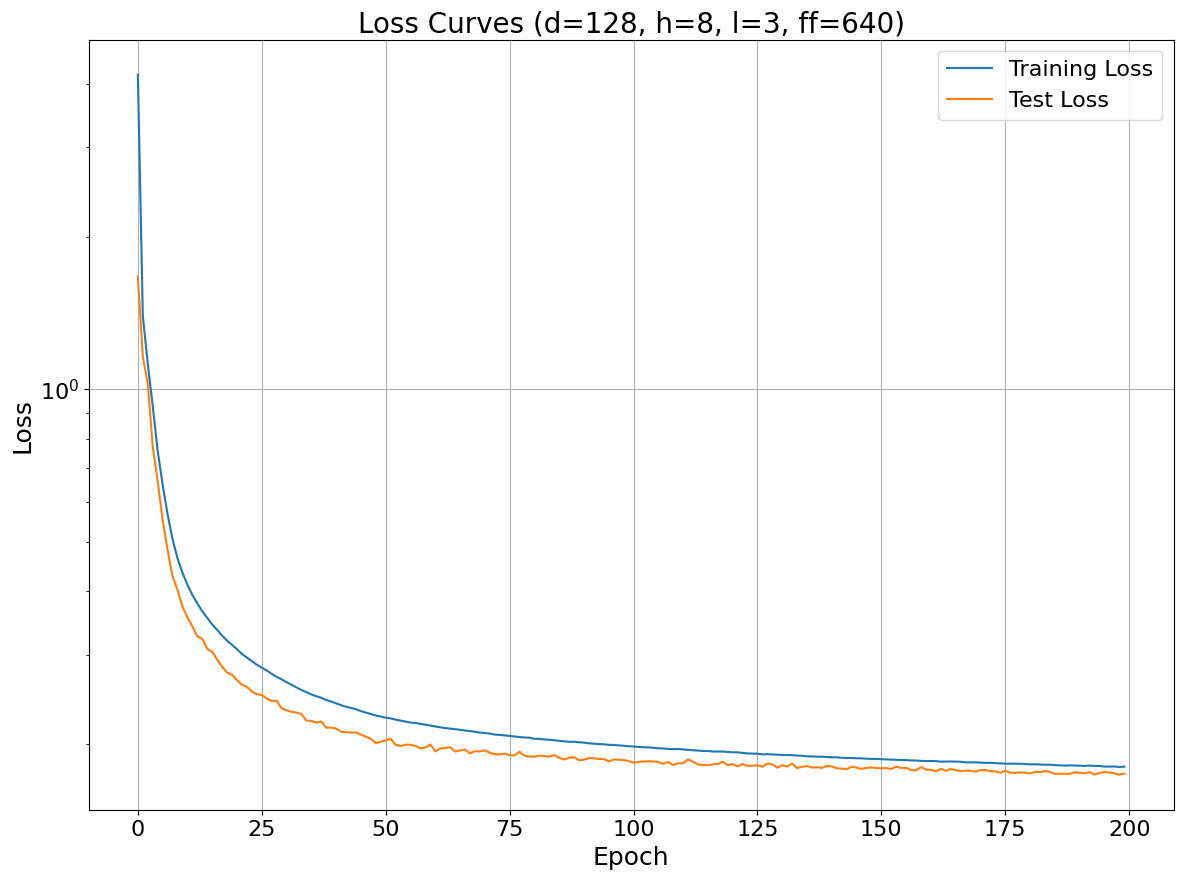

In [20]:
plot_loss_curves(
    train_losses,
    test_losses,
    d_model=config['d_model'],
    n_heads=config['n_heads'],
    n_layers=config['n_layers'],
    d_ff=config['d_ff']
    )

Biomass_Ecoli_core_flux:
------------------------------------------------------------
Biomass_Ecoli_core_flux global token index: 32
y_true range: 4.0233742765849456e-05 to 2.6499929428100586
y_pred range: -0.07789123058319092 to 2.4531726837158203


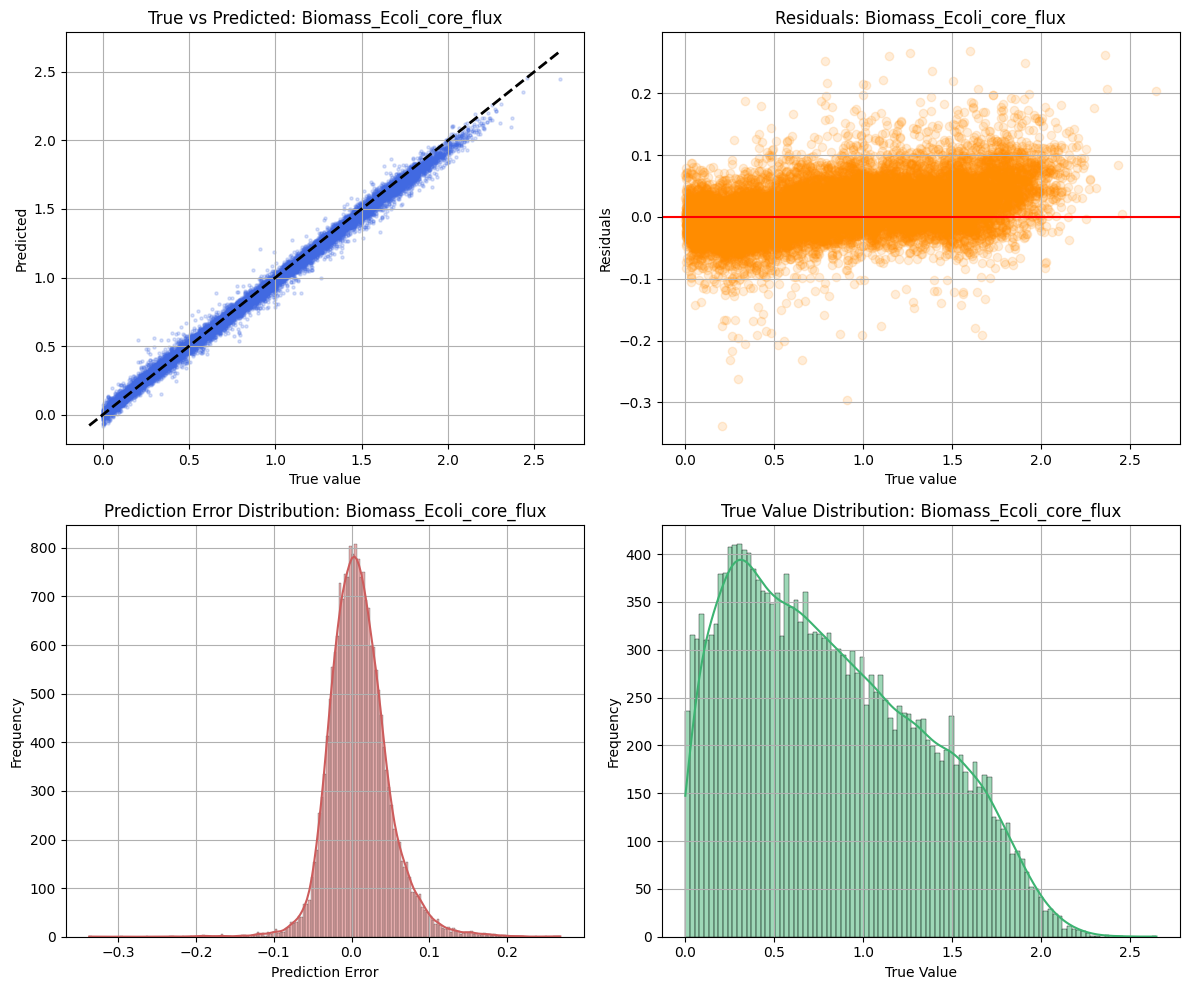

GLUDy_flux:
------------------------------------------------------------
GLUDy_flux global token index: 52
y_true range: -9.924531936645508 to 49.97012710571289
y_pred range: -10.121724128723145 to 24.59719467163086


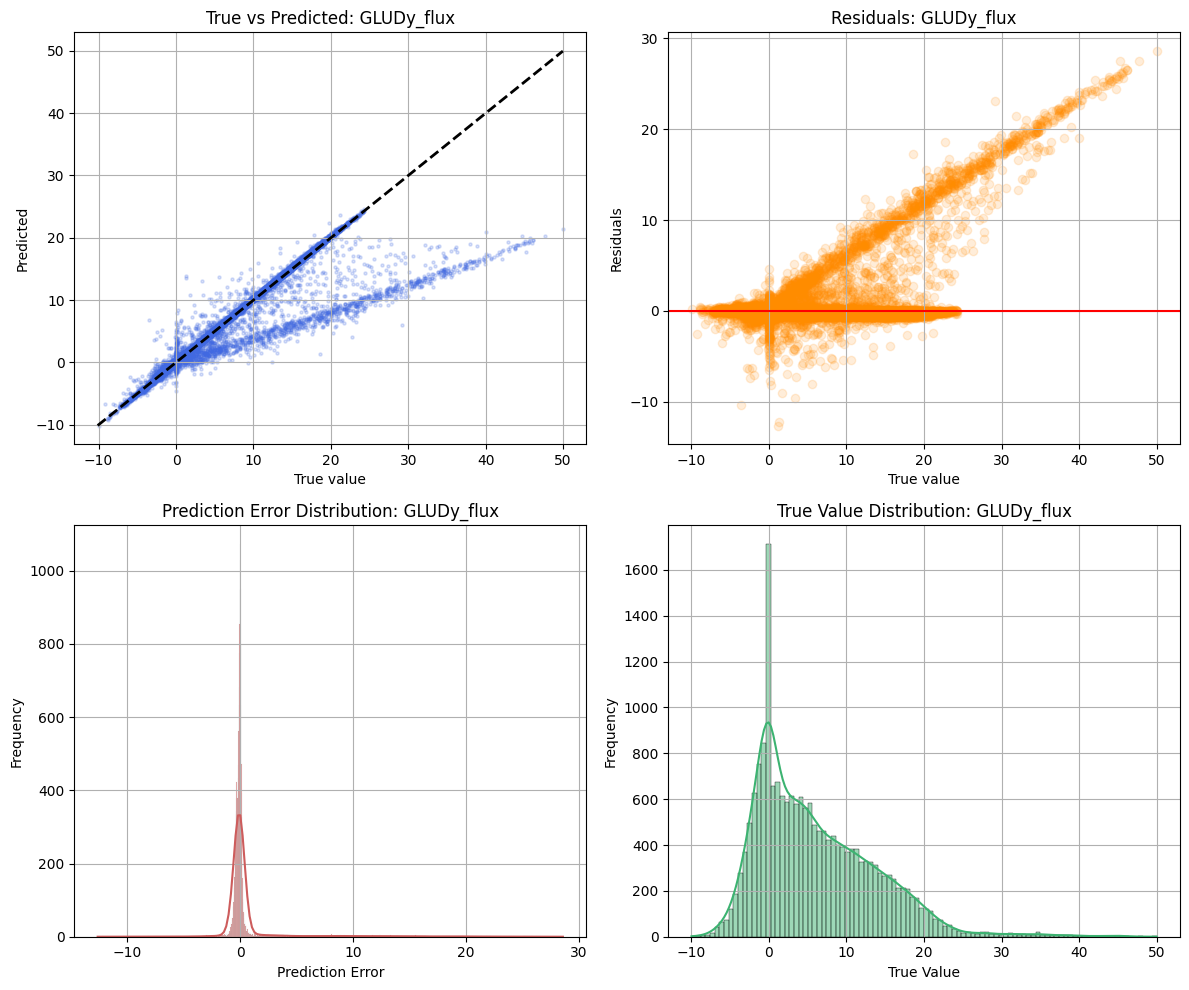

H2Ot_flux:
------------------------------------------------------------
H2Ot_flux global token index: 57
y_true range: -60.683223724365234 to 27.899232864379883
y_pred range: -59.490379333496094 to 27.287412643432617


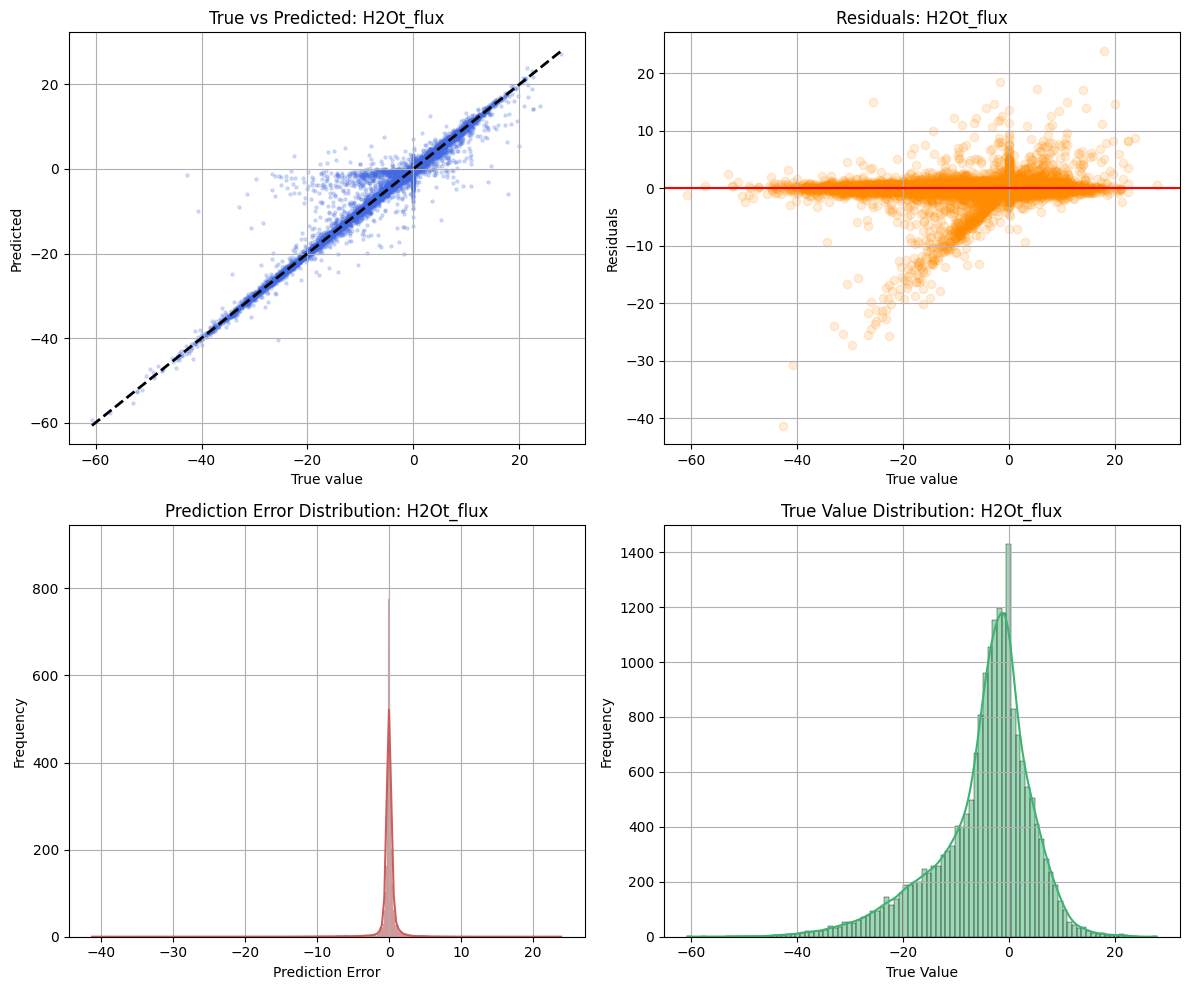

SUCCt3_flux:
------------------------------------------------------------
SUCCt3_flux global token index: 87
y_true range: -1.0446964474053466e-12 to 16.208797454833984
y_pred range: -0.3465149402618408 to 14.204802513122559


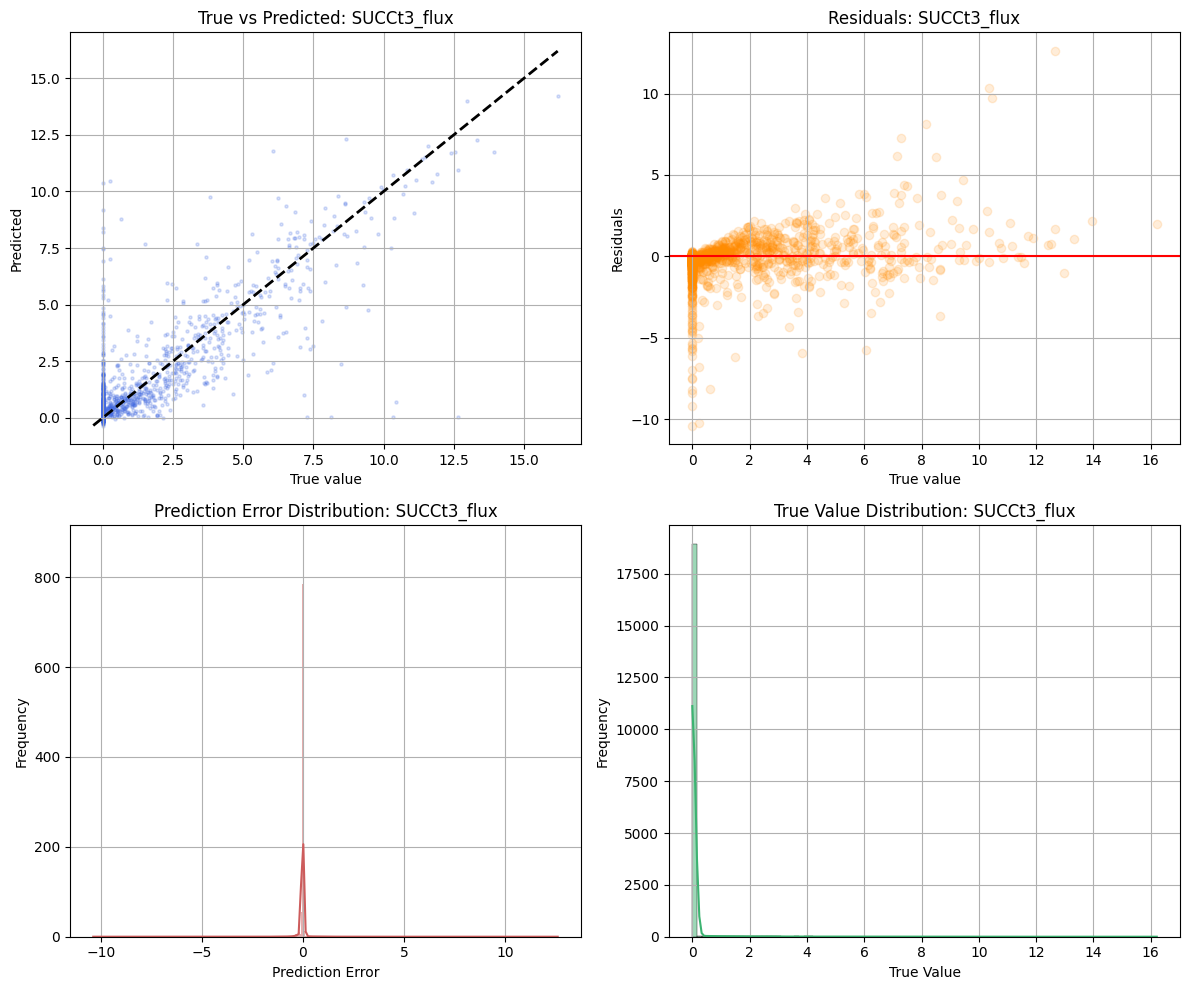

GLUN_flux:
------------------------------------------------------------
GLUN_flux global token index: 53
y_true range: -9.76646352359627e-15 to 28.625926971435547
y_pred range: -0.29427897930145264 to 27.661909103393555


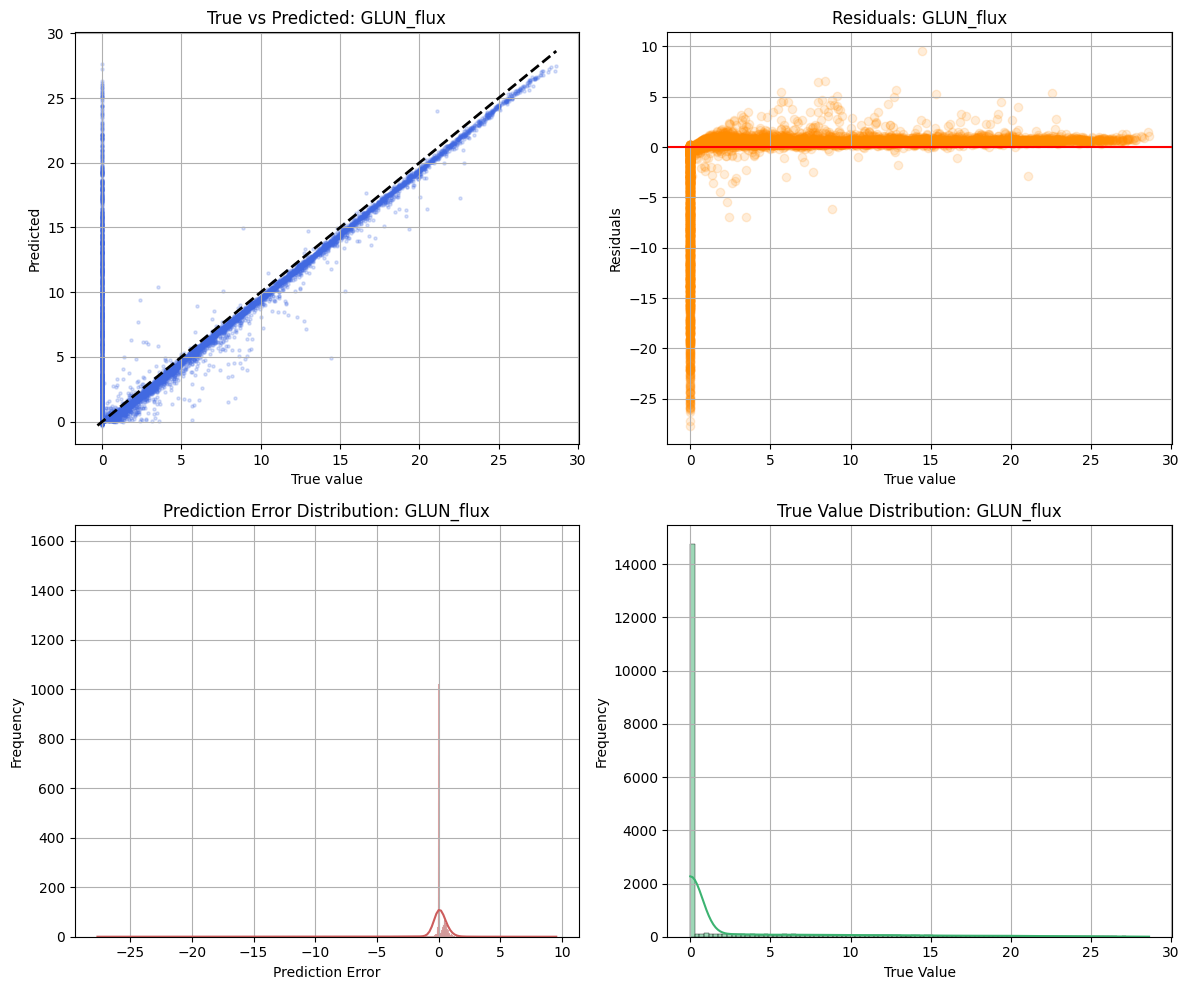

PGM_flux:
------------------------------------------------------------
PGM_flux global token index: 76
y_true range: -33.516029357910156 to 8.295674324035645
y_pred range: -33.598609924316406 to 8.232771873474121


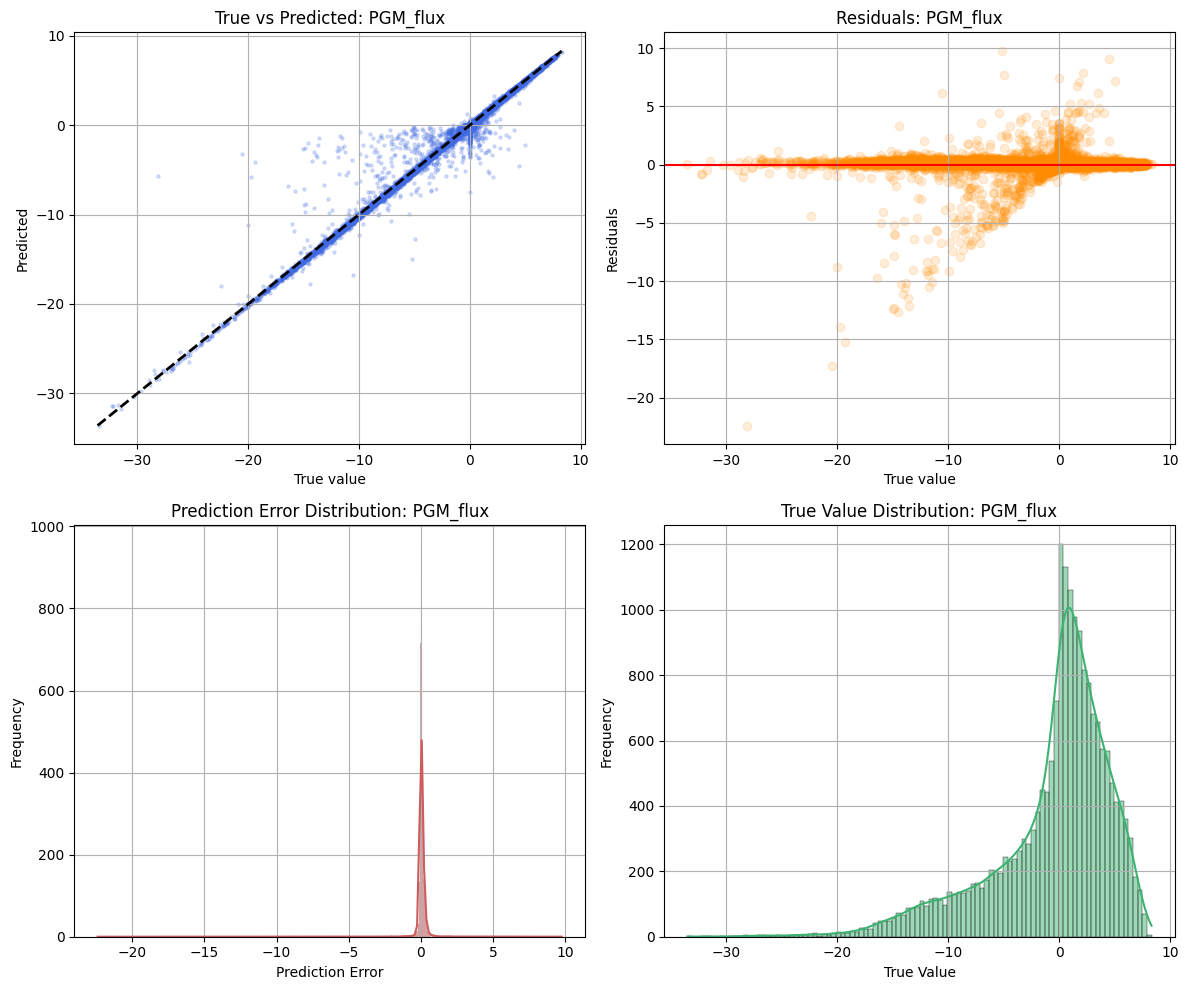

In [21]:
diagnostics_to_plot = ['Biomass_Ecoli_core_flux', 'GLUDy_flux', 'H2Ot_flux', 'SUCCt3_flux', 'GLUN_flux', 'PGM_flux']

for flux_name in diagnostics_to_plot:
    save_path = f"{pic_dir}/{flux_name}"
    print(f'{flux_name}:')
    print(60 * '-')
    plot_flux(model, X_test, y_test, outputs_ordered, f"{flux_name}", save_path=None, K=K)
    #plot_flux(model, X_test, y_test, true_output_cols, f"{flux_name}", save_path=None, K=K)

EX_glc__D_e_flux global token index: 0
y_true range: 0.0 to 0.0
y_pred range: -0.09309625625610352 to 0.3305619955062866


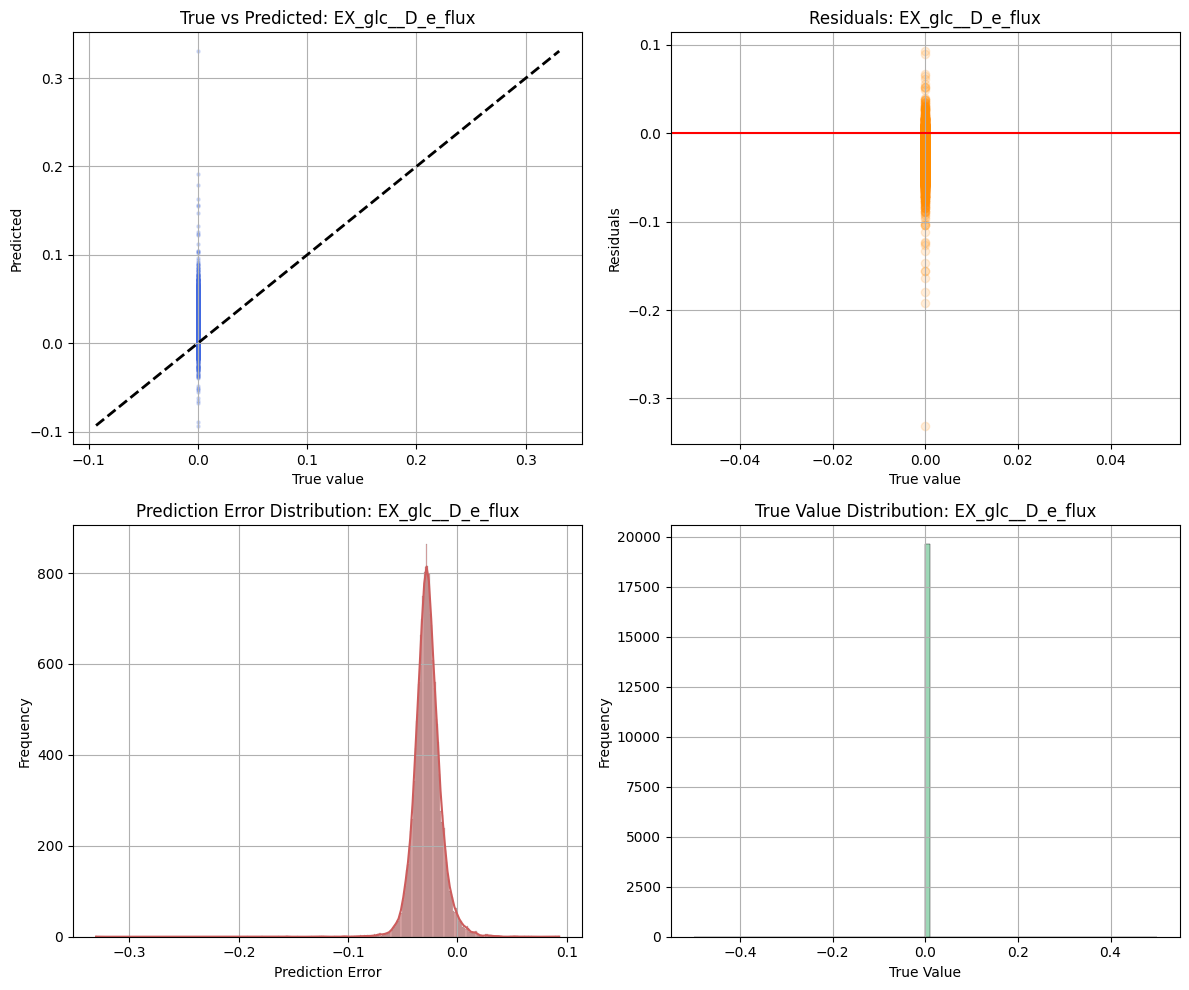

In [22]:
plot_flux(model, X_test, y_test, outputs_ordered, "EX_glc__D_e_flux", K=K)

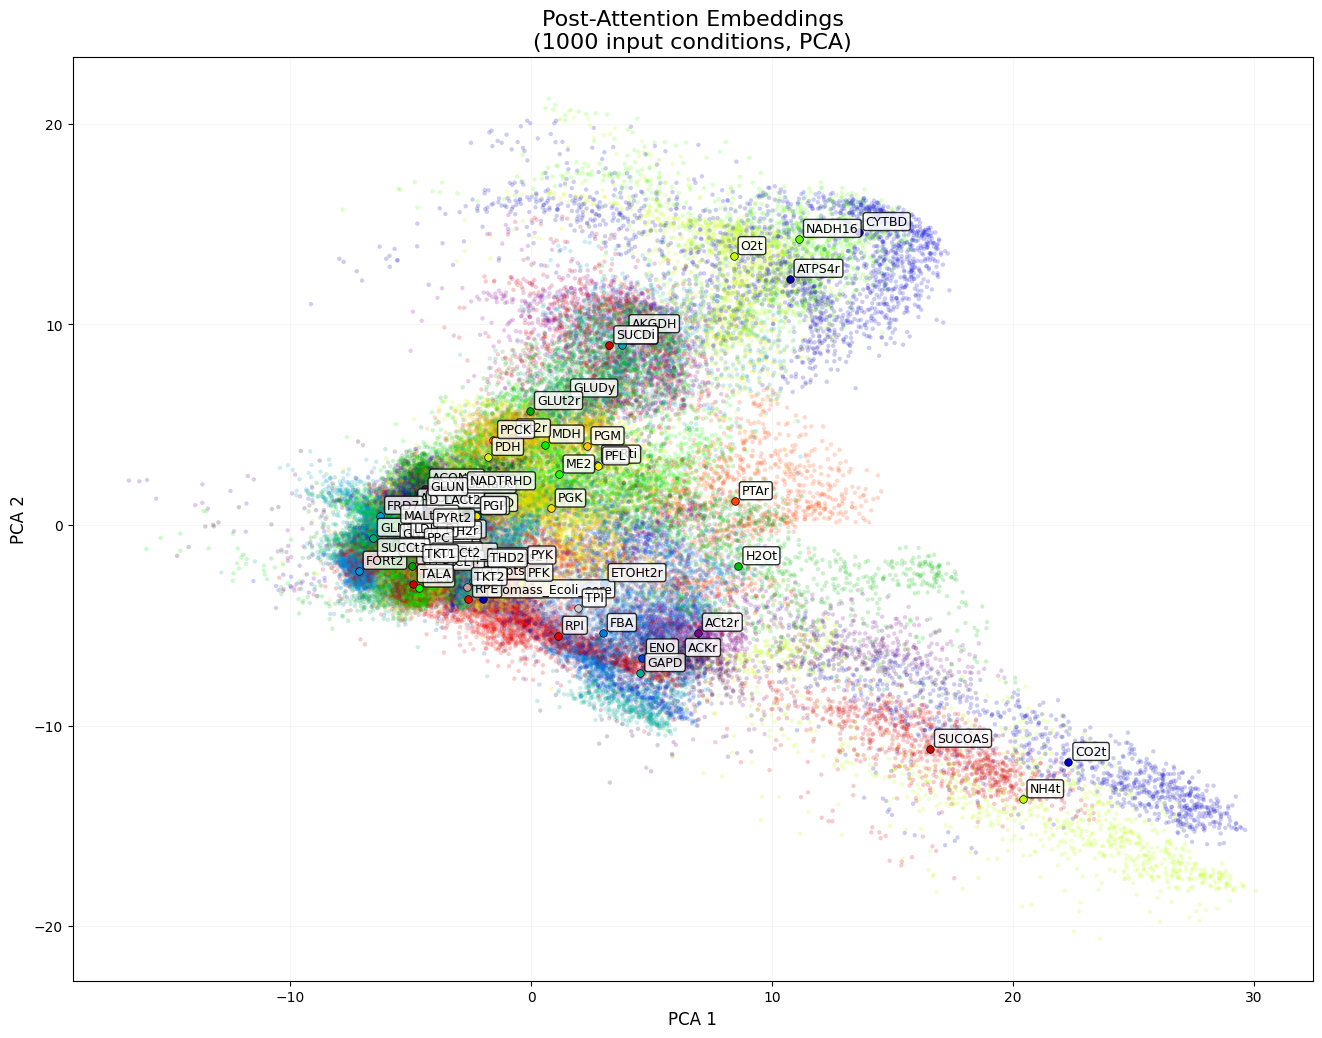

In [23]:
plot_post_attention_real_context(model, true_output_cols, X_test, K=K, method='pca', n_components=2, n_samples=1000)

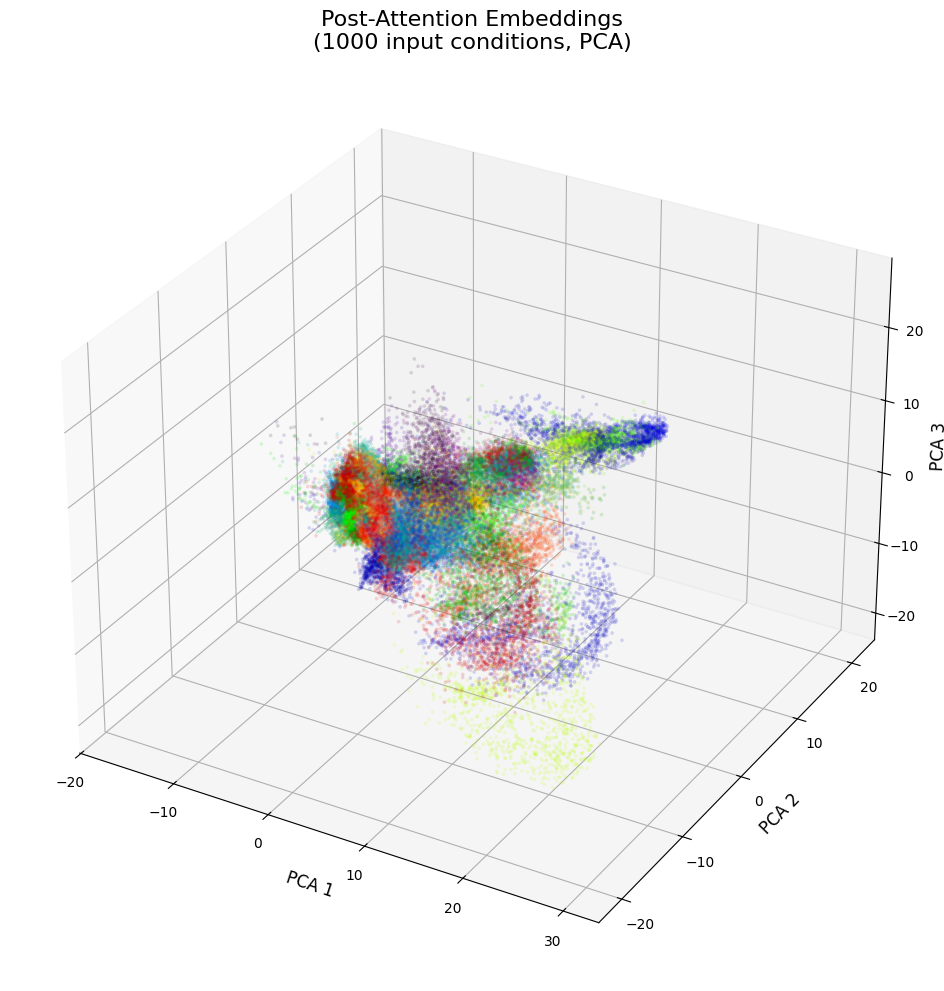

In [24]:

plot_post_attention_real_context(model, true_output_cols, X_test, K=K, method='pca',  n_components=3, n_samples=1000)

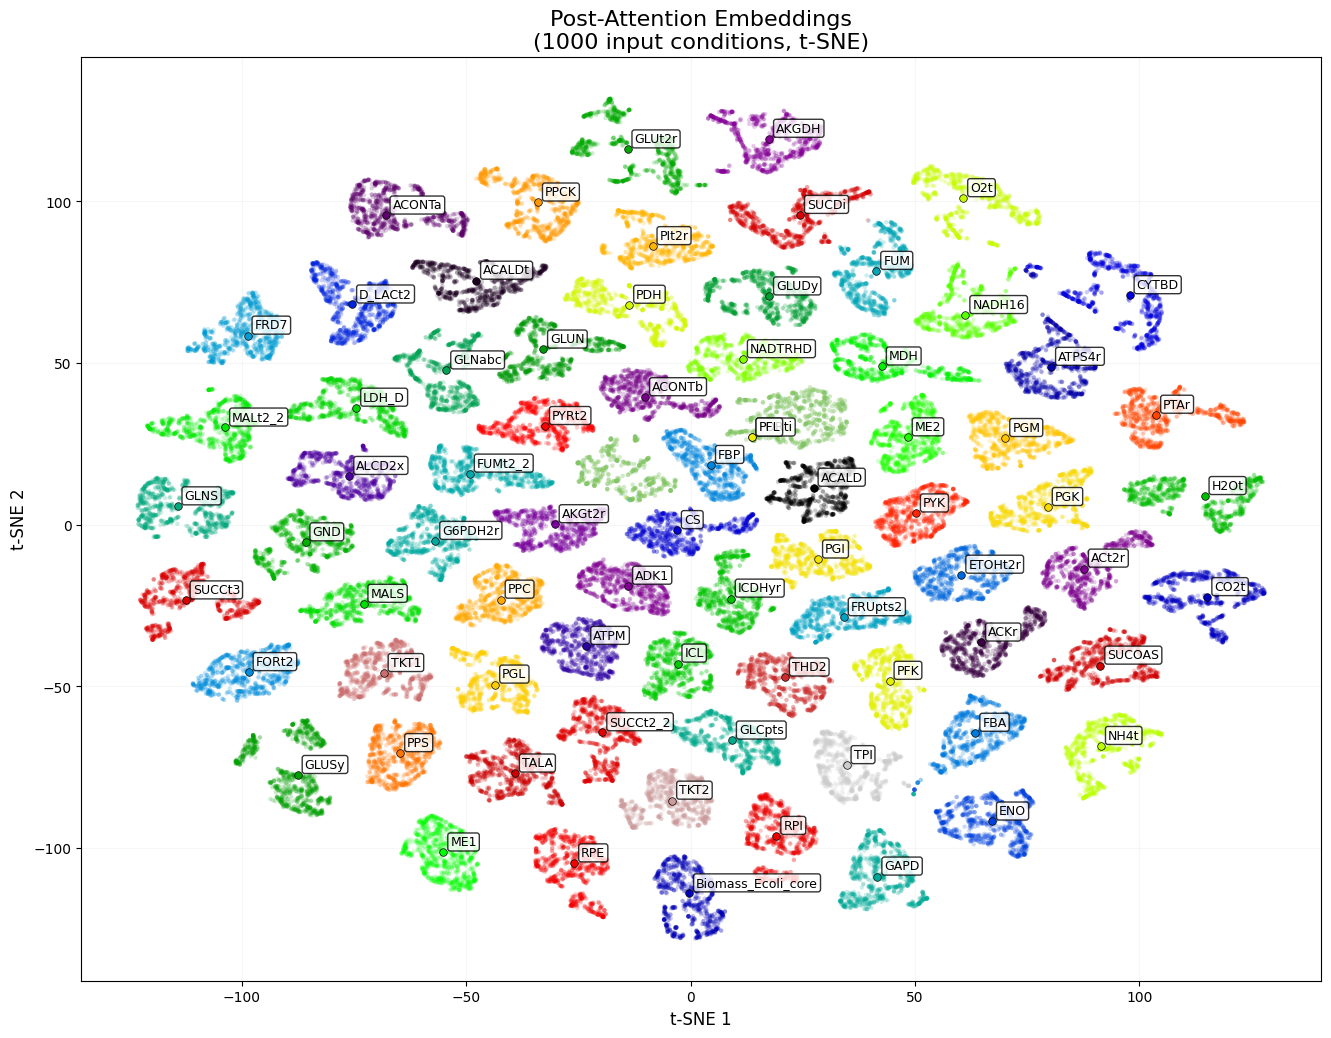

In [25]:
plot_post_attention_real_context(model, true_output_cols, X_test, K=K, method='tsne', n_components=2, n_samples=1000, perplexity=30.0)

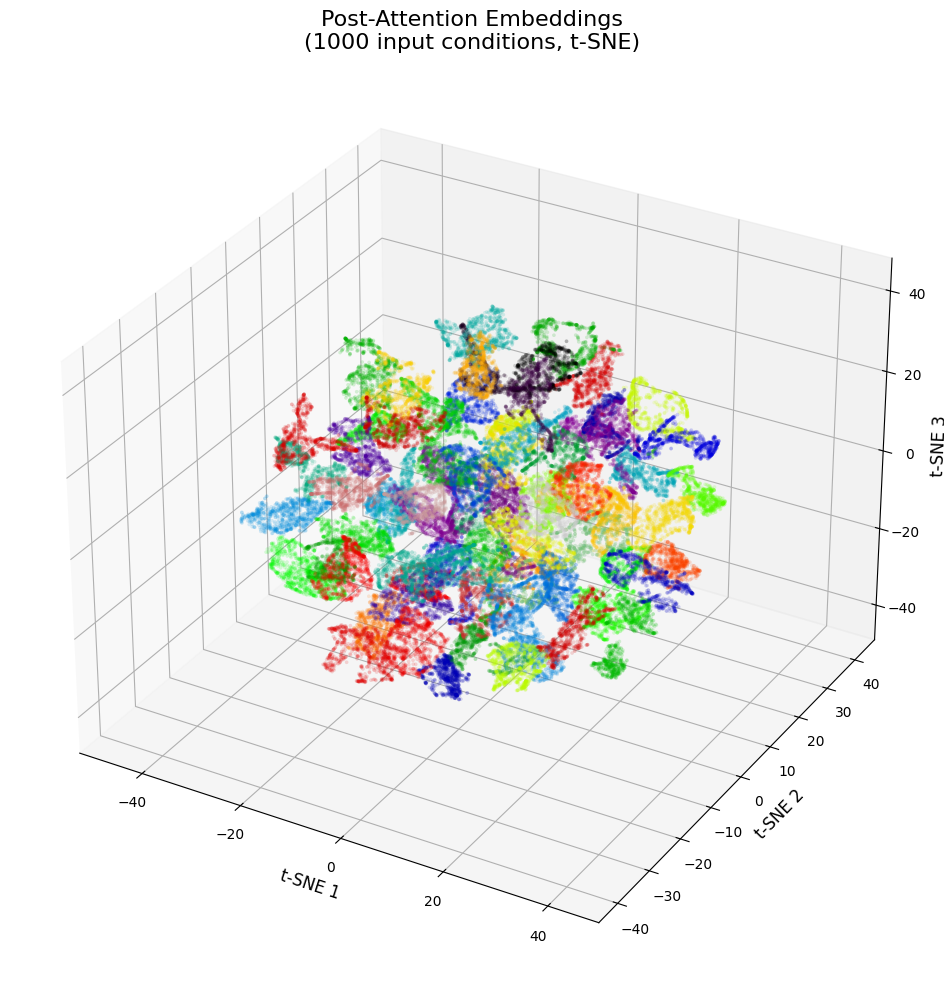

In [26]:
plot_post_attention_real_context(model, true_output_cols, X_test, K=K, method='tsne', n_components=3, n_samples=1000, perplexity=40.0)

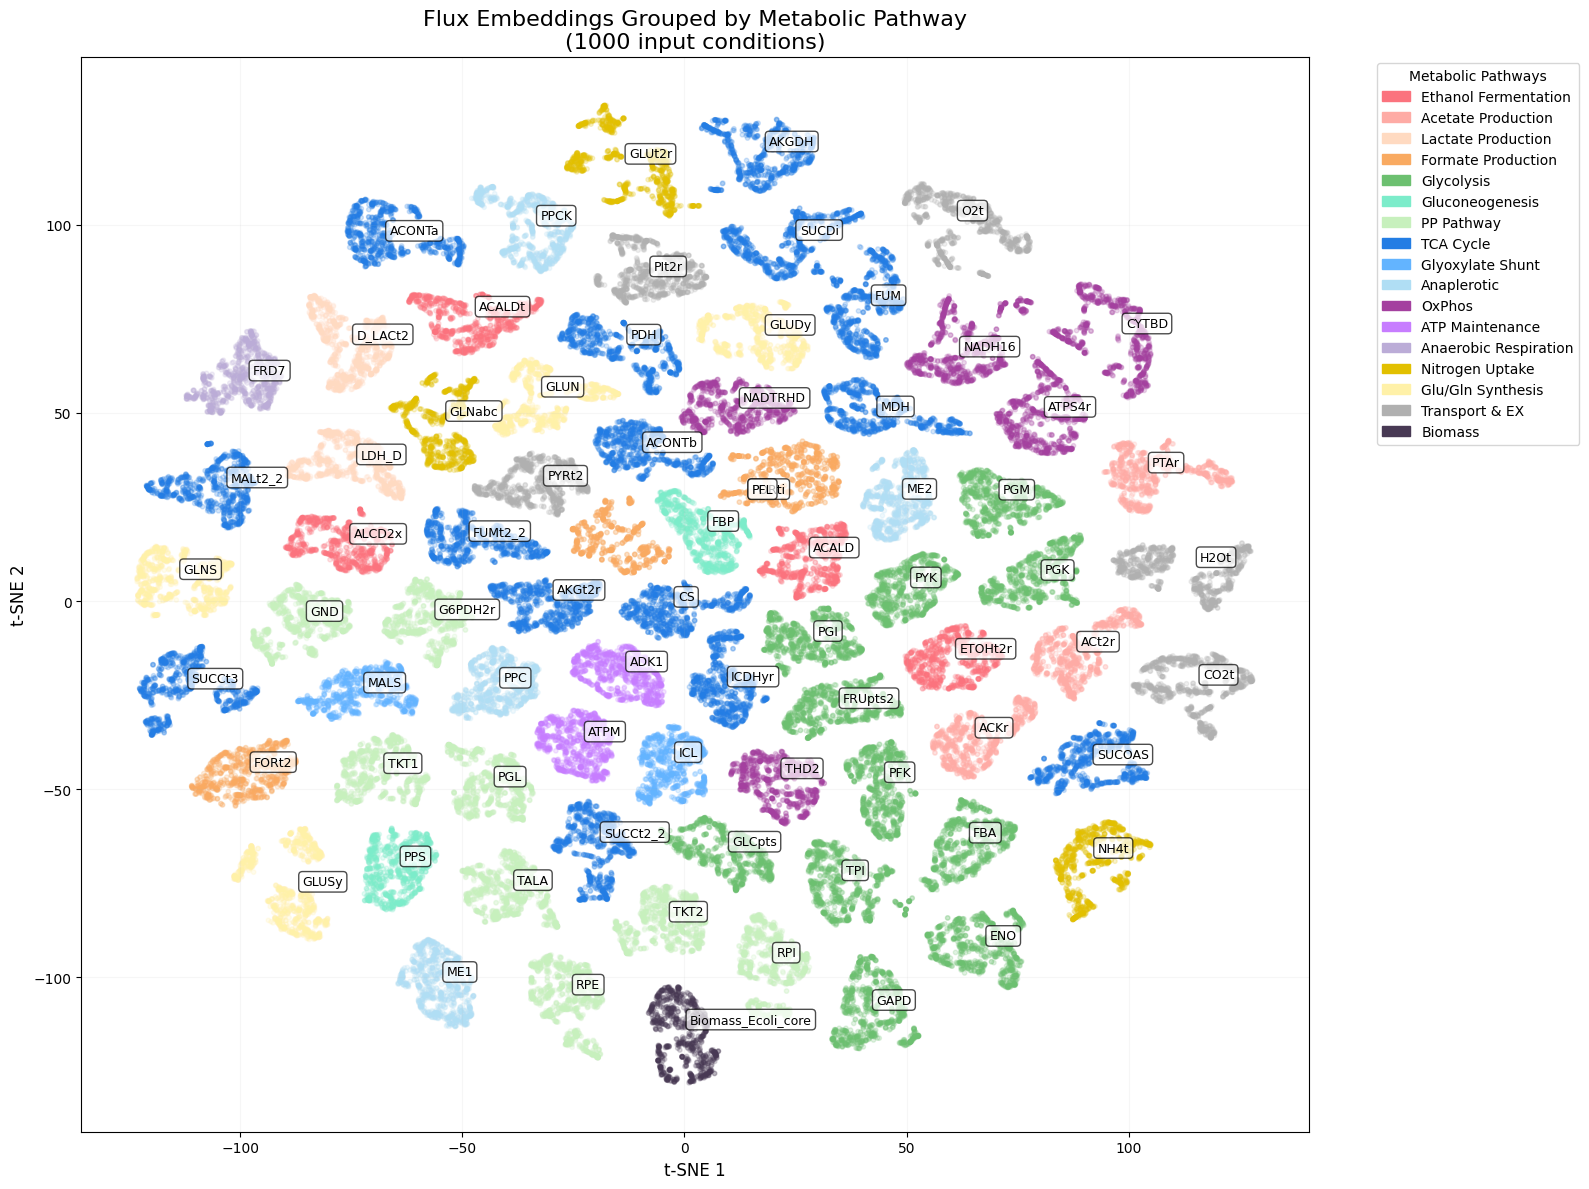

In [27]:
plot_post_attention_grouped_tsne(
    model,
    true_output_cols,
    X_test[:1000],
    n_samples=1000,
    perplexity=30,
    save_path=None,
    K=K
)

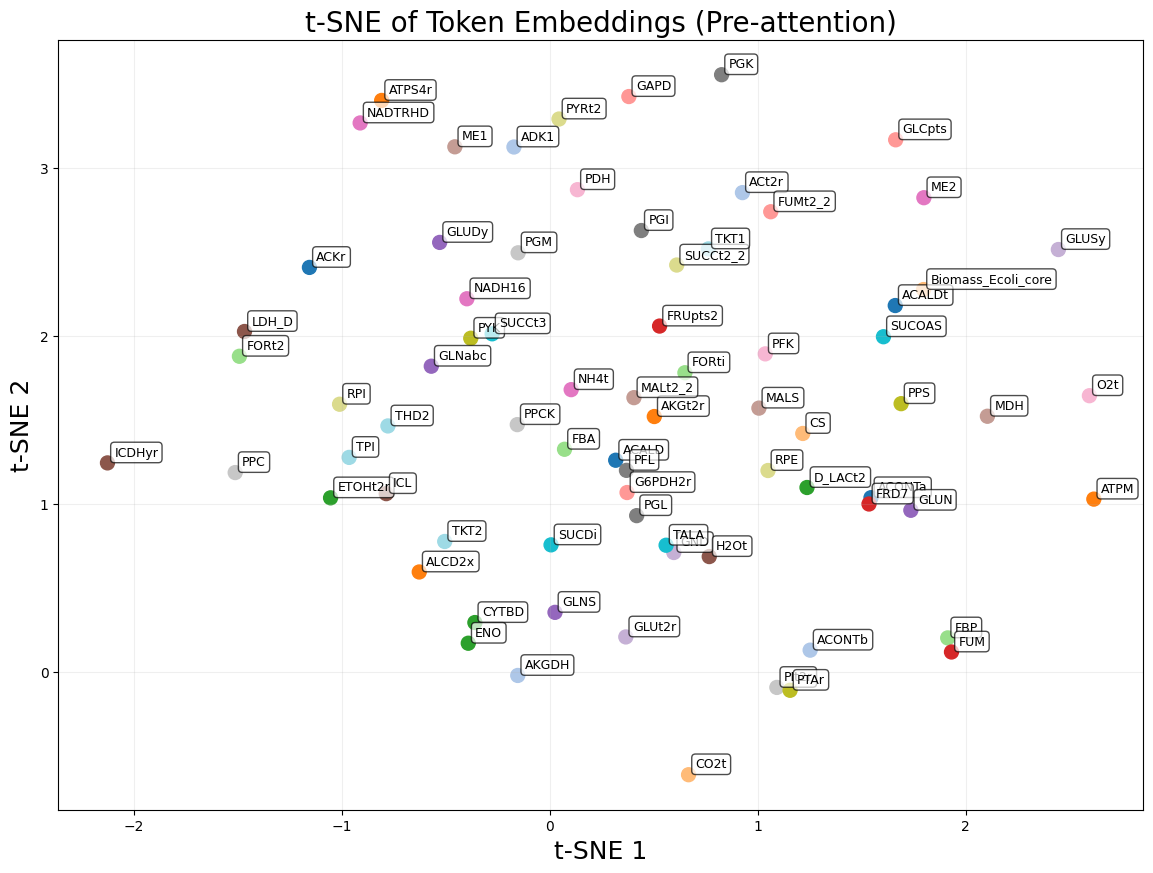

In [28]:
# pre-attention embeddings

plot_pre_attention_embeddings_tsne(model, true_output_cols, K=K)

c:\Users\truok\Documents\metabolic-NN\venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


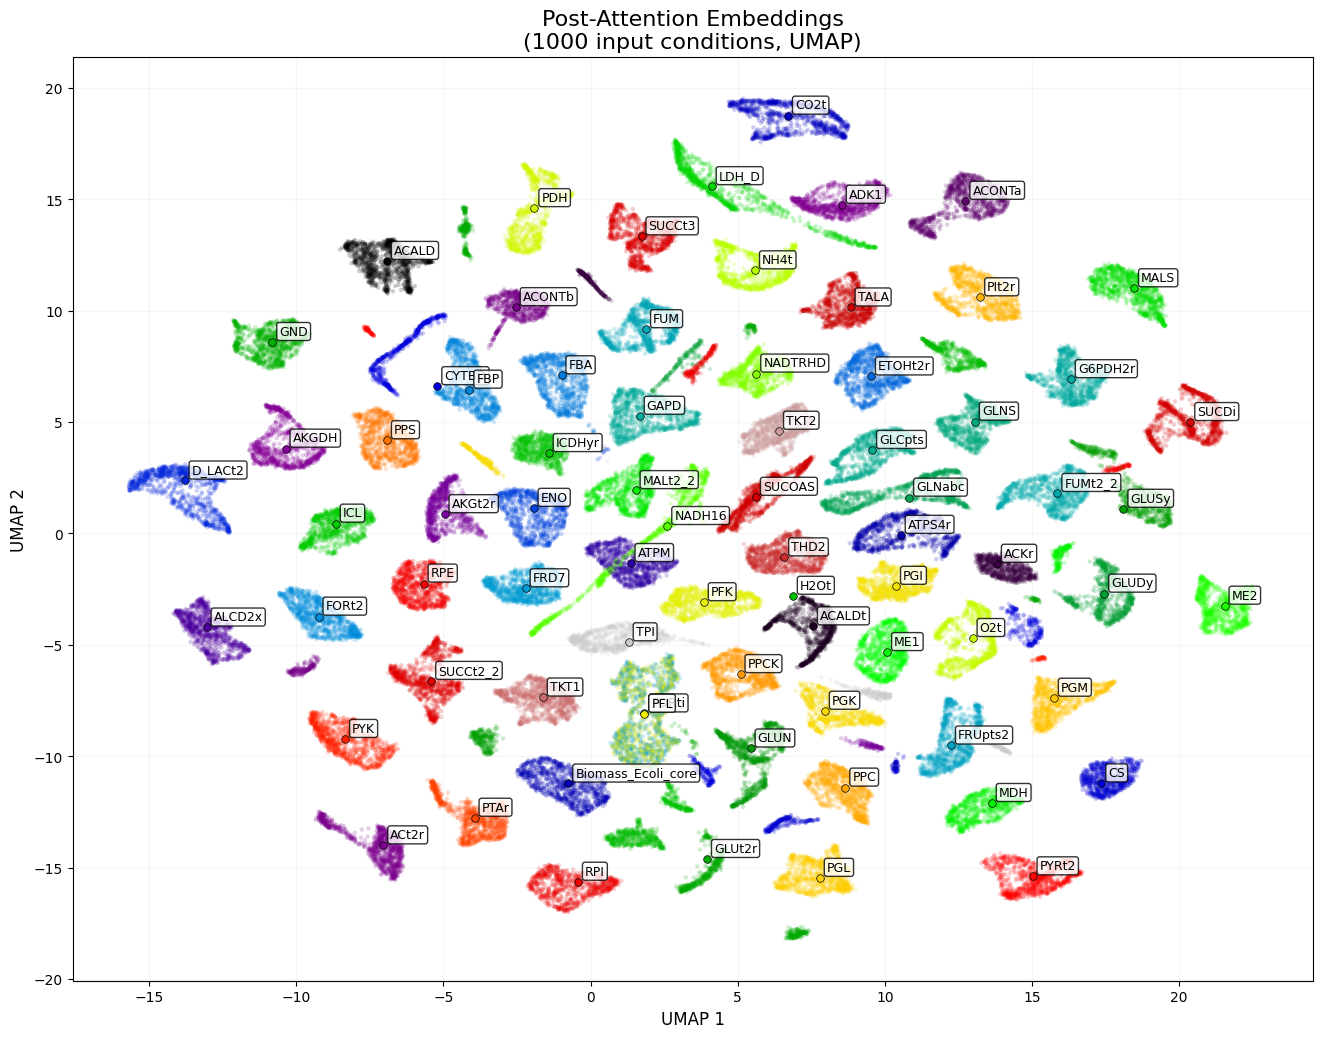

In [29]:
plot_post_attention_real_context(model, true_output_cols, X_test, K=K, method='umap', n_components=2, n_neighbors=50, min_dist=0.5)

In [30]:
metrics = []

model_cpu = model.to('cpu').eval()

with torch.no_grad():
    preds_all_layers, selected_indices = model_cpu(X_test.unsqueeze(-1).to('cpu'), output_subset=None)
    # preds_all_layers: (N, V, n_layers)
    y_pred_full = preds_all_layers[:, :, -1].cpu().numpy()   # (N, V)

y_true_full = y_test.cpu().numpy()                            # (N, V)

# Only true outputs (exclude injected input slots)
y_pred = y_pred_full[:, K:]  # (N, 95)
y_true = y_true_full[:, K:]  # (N, 95)

for i, label in enumerate(true_output_cols):
    r2 = r2_score(y_true[:, i], y_pred[:, i])
    mae = mean_absolute_error(y_true[:, i], y_pred[:, i])
    metrics.append({'flux': label.replace('_flux',''), 'r2': r2, 'mae': mae})

df_metrics = pd.DataFrame(metrics)[['flux', 'r2', 'mae']]
df_metrics['r2'] = df_metrics['r2'].map('{:.3f}'.format)
df_metrics['mae'] = df_metrics['mae'].map('{:.4f}'.format)

print("\nModel Evaluation Metrics:\n")
display(df_metrics)


Model Evaluation Metrics:



,flux,r2,mae
0,ACALD,0.960,0.1999
1,ACALDt,0.986,0.0638
2,ACKr,0.970,0.3903
3,ACONTa,0.958,0.1317
4,ACONTb,0.957,0.1331
5,ACt2r,0.969,0.3733
6,ADK1,0.734,0.0268
7,AKGDH,0.995,0.2399
8,AKGt2r,0.990,0.0389
9,ALCD2x,0.947,0.1675


In [31]:
'''
animate_real_context_tsne(
    model, true_output_cols, X_test,
    n_samples=1000, perplexity=20, n_iter=200, step=1,
    gif_path=f"{pic_dir}/tsne_animation.gif",
    K=20,
    target_radius=0.95,
    fixed_lim=1.0
)
'''

'\nanimate_real_context_tsne(\n    model, true_output_cols, X_test,\n    n_samples=1000, perplexity=20, n_iter=200, step=1,\n    gif_path=f"{pic_dir}/tsne_animation.gif",\n    K=20,\n    target_radius=0.95,\n    fixed_lim=1.0\n)\n'